# 🐱 Pipeline: Detecção + Classificação de Raça de Gatos

Este notebook implementa o pipeline completo:

1. **Detecção**: localizar o gato na imagem (bounding box) usando YOLOv8 pré-treinado
2. **Classificação**: recortar a região do gato e classificar a raça (transfer learning com ResNet)
3. **Grad-CAM**: visualizar o que o modelo "olhou" para decidir a raça
4. **Teste em fotos reais**: avaliar generalização em imagens fora do dataset

Dataset: [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)

> Rode as células em ordem. As seções estão marcadas com `##`.


## 1. Setup — instalação de dependências

In [ ]:
!pip install -q ultralytics torch torchvision grad-cam scikit-learn matplotlib seaborn pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.7 MB/s eta 0:00:00


In [ ]:
import os
import glob
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from torchvision.transforms import functional as TF

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


Usando device: cuda


## 2. Download do dataset (Oxford-IIIT Pet)

O dataset contém cães e gatos. Vamos baixar as imagens e as anotações
(que incluem a raça e, para um subconjunto, bounding boxes no estilo Pascal VOC).


In [ ]:
DATA_DIR = "/content/oxford_pets"
os.makedirs(DATA_DIR, exist_ok=True)

# Imagens
!wget -q -N https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz -P {DATA_DIR}
# Anotações (classes, trainval/test split, bounding boxes em xmls/)
!wget -q -N https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz -P {DATA_DIR}

!tar -xzf {DATA_DIR}/images.tar.gz -C {DATA_DIR}
!tar -xzf {DATA_DIR}/annotations.tar.gz -C {DATA_DIR}

print("Download e extração concluídos.")


Download e extração concluídos.


In [ ]:
IMAGES_DIR = os.path.join(DATA_DIR, "images")
ANNOT_DIR = os.path.join(DATA_DIR, "annotations")

# O arquivo list.txt mapeia: nome_arquivo classe_id espécie(1=gato,2=cachorro) breed_id
list_path = os.path.join(ANNOT_DIR, "list.txt")
rows = []
with open(list_path) as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split()
        if len(parts) != 4:
            continue
        filename, class_id, species, breed_id = parts
        rows.append((filename, int(class_id), int(species), int(breed_id)))

df = pd.DataFrame(rows, columns=["filename", "class_id", "species", "breed_id"])

# species == 1 -> gato. Filtramos só os gatos.
cats_df = df[df["species"] == 1].copy()

# Nome da raça = prefixo do nome do arquivo antes do número (ex: "Abyssinian_100" -> "Abyssinian")
cats_df["breed_name"] = cats_df["filename"].apply(lambda x: "_".join(x.split("_")[:-1]))
cats_df["filepath"] = cats_df["filename"].apply(lambda x: os.path.join(IMAGES_DIR, x + ".jpg"))
cats_df = cats_df[cats_df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total de imagens de gatos: {len(cats_df)}")
print(f"Raças encontradas ({cats_df['breed_name'].nunique()}):")
print(sorted(cats_df["breed_name"].unique()))
cats_df.head()


Total de imagens de gatos: 2371
Raças encontradas (12):
['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx']


,filename,class_id,species,breed_id,breed_name,filepath
0,Abyssinian_100,1,1,1,Abyssinian,/content/oxford_pets/images/Abyssinian_100.jpg
1,Abyssinian_101,1,1,1,Abyssinian,/content/oxford_pets/images/Abyssinian_101.jpg
2,Abyssinian_102,1,1,1,Abyssinian,/content/oxford_pets/images/Abyssinian_102.jpg
3,Abyssinian_103,1,1,1,Abyssinian,/content/oxford_pets/images/Abyssinian_103.jpg
4,Abyssinian_104,1,1,1,Abyssinian,/content/oxford_pets/images/Abyssinian_104.jpg


## 3. Preparar labels e splits

Criamos o mapeamento raça → índice numérico e dividimos em treino/validação/teste.


In [ ]:
breed_names = sorted(cats_df["breed_name"].unique())
breed_to_idx = {b: i for i, b in enumerate(breed_names)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}
NUM_CLASSES = len(breed_names)

cats_df["label"] = cats_df["breed_name"].map(breed_to_idx)

# Split estratificado simples: 70% treino, 15% val, 15% teste
train_list, val_list, test_list = [], [], []
for breed in breed_names:
    sub = cats_df[cats_df["breed_name"] == breed].sample(frac=1, random_state=42)
    n = len(sub)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_list.append(sub.iloc[:n_train])
    val_list.append(sub.iloc[n_train:n_train + n_val])
    test_list.append(sub.iloc[n_train + n_val:])

train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

print(f"Treino: {len(train_df)} | Validação: {len(val_df)} | Teste: {len(test_df)}")


Treino: 1658 | Validação: 353 | Teste: 360


## 4. Dataset e DataLoaders (PyTorch)

In [ ]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CatBreedDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]


train_ds = CatBreedDataset(train_df, transform=train_tfms)
val_ds = CatBreedDataset(val_df, transform=eval_tfms)
test_ds = CatBreedDataset(test_df, transform=eval_tfms)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders prontos.")


DataLoaders prontos.


## 5. Modelo de classificação (Transfer Learning — ResNet50)

Usamos uma ResNet50 pré-treinada na ImageNet e substituímos a última camada
pelo número de raças de gato. Congelamos as camadas iniciais e treinamos
apenas o "topo" da rede (fine-tuning parcial).


In [ ]:
def build_model(num_classes, freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Substitui a última camada (fc) pelo número de raças
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)


model = build_model(NUM_CLASSES, freeze_backbone=True)
print(model.fc)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


Linear(in_features=2048, out_features=12, bias=True)


## 6. Treinamento

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 15


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += imgs.size(0)

    return total_loss / total_samples, total_correct / total_samples


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")


Epoch 1/15 | Train loss: 1.8088 acc: 0.5935 | Val loss: 1.2270 acc: 0.8159
Epoch 2/15 | Train loss: 0.9755 acc: 0.8468 | Val loss: 0.8158 acc: 0.8300
Epoch 3/15 | Train loss: 0.6767 acc: 0.8800 | Val loss: 0.6470 acc: 0.8612
Epoch 4/15 | Train loss: 0.5455 acc: 0.9065 | Val loss: 0.5514 acc: 0.8725
Epoch 5/15 | Train loss: 0.4478 acc: 0.9144 | Val loss: 0.4944 acc: 0.8924
Epoch 6/15 | Train loss: 0.4133 acc: 0.9138 | Val loss: 0.4791 acc: 0.8754
Epoch 7/15 | Train loss: 0.3737 acc: 0.9367 | Val loss: 0.4495 acc: 0.8754
Epoch 8/15 | Train loss: 0.3592 acc: 0.9264 | Val loss: 0.4450 acc: 0.8839
Epoch 9/15 | Train loss: 0.3517 acc: 0.9324 | Val loss: 0.4201 acc: 0.8867
Epoch 10/15 | Train loss: 0.3293 acc: 0.9355 | Val loss: 0.4222 acc: 0.8754
Epoch 11/15 | Train loss: 0.3066 acc: 0.9457 | Val loss: 0.4217 acc: 0.8810
Epoch 12/15 | Train loss: 0.2931 acc: 0.9524 | Val loss: 0.4097 acc: 0.8810
Epoch 13/15 | Train loss: 0.2888 acc: 0.9493 | Val loss: 0.4036 acc: 0.8839
Epoch 14/15 | Train l

In [ ]:
# Opcional: fine-tuning das últimas camadas convolucionais para ganhar mais performance
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

FT_EPOCHS = 5
for epoch in range(FT_EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f"[Fine-tune] Epoch {epoch+1}/{FT_EPOCHS} | "
          f"Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}")


[Fine-tune] Epoch 1/5 | Train acc: 0.9475 | Val acc: 0.8924
[Fine-tune] Epoch 2/5 | Train acc: 0.9499 | Val acc: 0.9008
[Fine-tune] Epoch 3/5 | Train acc: 0.9584 | Val acc: 0.8895
[Fine-tune] Epoch 4/5 | Train acc: 0.9590 | Val acc: 0.9093
[Fine-tune] Epoch 5/5 | Train acc: 0.9644 | Val acc: 0.8867


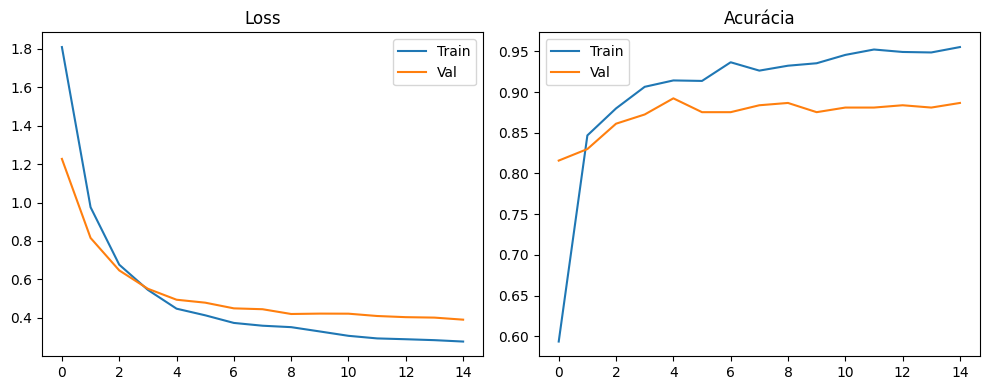

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Acurácia")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Avaliação no conjunto de teste (dataset)

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Acurácia no teste: {acc:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=breed_names))


Acurácia no teste: 0.8667
F1-score (macro): 0.8667

                   precision    recall  f1-score   support

       Abyssinian       0.76      0.90      0.82        31
           Bengal       0.85      0.73      0.79        30
           Birman       0.85      0.77      0.81        30
           Bombay       0.93      0.93      0.93        29
British_Shorthair       1.00      0.83      0.91        30
     Egyptian_Mau       0.74      0.90      0.81        29
       Maine_Coon       0.88      0.97      0.92        30
          Persian       0.92      0.80      0.86        30
          Ragdoll       0.79      0.77      0.78        30
     Russian_Blue       0.87      0.90      0.89        30
          Siamese       0.88      0.97      0.92        31
           Sphynx       1.00      0.93      0.97        30

         accuracy                           0.87       360
        macro avg       0.87      0.87      0.87       360
     weighted avg       0.87      0.87      0.87       360



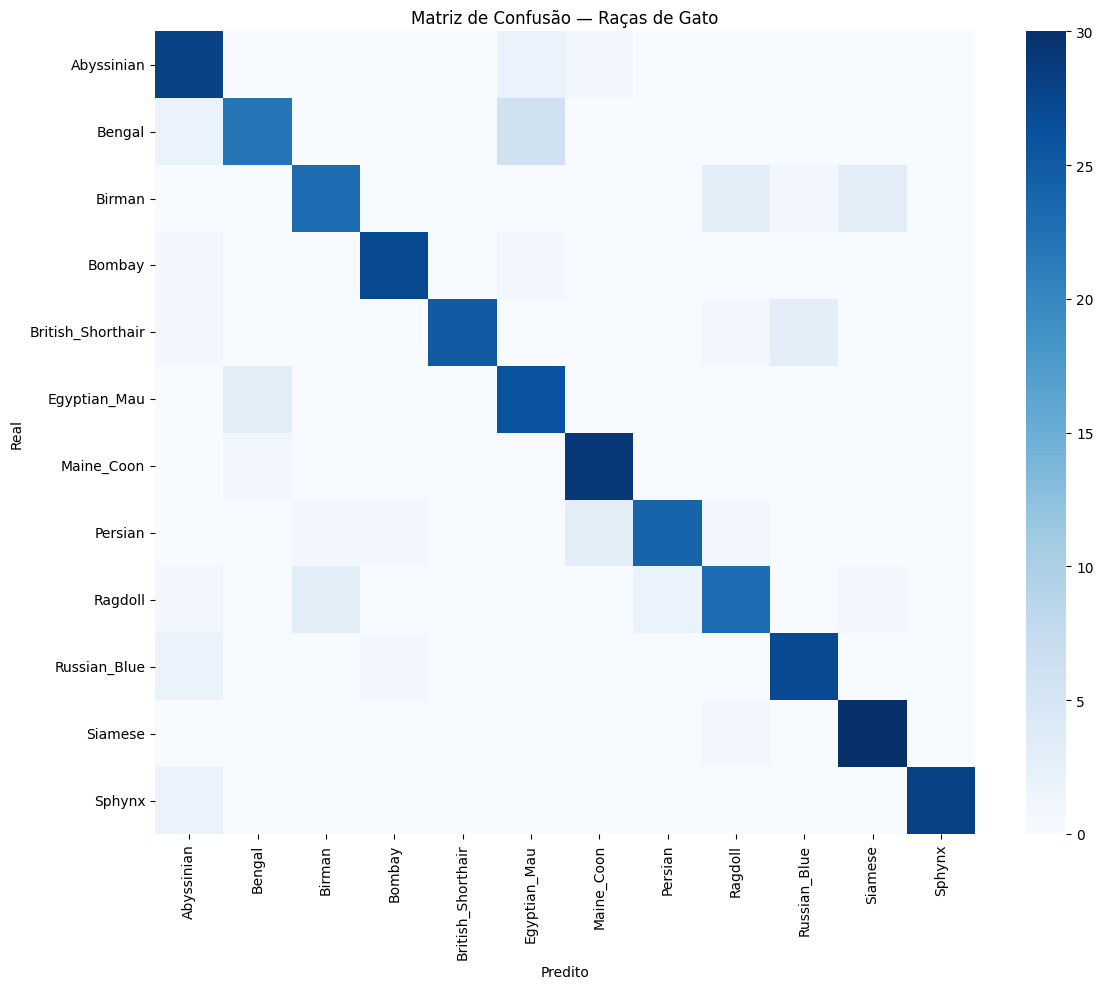

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
import seaborn as sns
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=breed_names, yticklabels=breed_names)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão — Raças de Gato")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Salva o modelo treinado
MODEL_PATH = "/content/cat_breed_classifier.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "breed_to_idx": breed_to_idx,
    "idx_to_breed": idx_to_breed,
}, MODEL_PATH)
print("Modelo salvo em", MODEL_PATH)


Modelo salvo em /content/cat_breed_classifier.pt


## 8. Detecção — YOLOv8 pré-treinado (classe "cat")

Usamos um YOLOv8 já treinado no COCO (que inclui a classe `cat`), sem
necessidade de treinar do zero. Ele nos dá a bounding box do gato na imagem.


In [ ]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")  # versão "nano": rápida e leve, ótima para este pipeline

# Índice da classe "cat" no COCO (dataset em que o YOLO foi treinado)
COCO_CAT_CLASS_ID = 15


def detect_cat_bbox(image_path, conf_threshold=0.25):
    """Retorna a bounding box (x1, y1, x2, y2) do gato com maior confiança,
    ou None se nenhum gato for detectado."""
    results = yolo_model(image_path, verbose=False)[0]

    best_box = None
    best_conf = 0.0

    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        if cls_id == COCO_CAT_CLASS_ID and conf > conf_threshold and conf > best_conf:
            best_conf = conf
            best_box = box.xyxy[0].cpu().numpy()  # [x1, y1, x2, y2]

    return best_box, best_conf


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


## 9. Grad-CAM

Vamos usar a biblioteca `pytorch-grad-cam` para gerar o mapa de calor
sobre a região que o classificador "olhou" para decidir a raça.


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Última camada convolucional da ResNet50 (boa escolha padrão para Grad-CAM)
target_layers = [model.layer4[-1]]
gradcam = GradCAM(model=model, target_layers=target_layers)


def generate_gradcam(pil_crop_img):
    """Recebe um crop PIL do gato (RGB) e retorna:
    - a imagem com heatmap sobreposto (numpy uint8)
    - a classe prevista (nome da raça)
    - a confiança da predição
    """
    img_resized = pil_crop_img.resize((IMG_SIZE, IMG_SIZE))
    rgb_img = np.array(img_resized).astype(np.float32) / 255.0

    input_tensor = eval_tfms(pil_crop_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = int(probs.argmax())
        pred_conf = float(probs[pred_idx])

    grayscale_cam = gradcam(input_tensor=input_tensor,
                             targets=[ClassifierOutputTarget(pred_idx)])[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    return cam_image, idx_to_breed[pred_idx], pred_conf


## 10. Pipeline completo: Detecção → Crop → Classificação → Grad-CAM

Esta é a função principal que junta tudo. Dado o caminho de uma imagem,
ela detecta o gato, recorta, classifica a raça e gera o Grad-CAM.


In [ ]:
import cv2


def full_pipeline(image_path, show=True):
    original = Image.open(image_path).convert("RGB")

    bbox, det_conf = detect_cat_bbox(image_path)

    if bbox is None:
        print(f"⚠️  Nenhum gato detectado em {image_path}")
        crop = original  # fallback: usa a imagem inteira
        bbox_used = None
    else:
        x1, y1, x2, y2 = map(int, bbox)
        crop = original.crop((x1, y1, x2, y2))
        bbox_used = (x1, y1, x2, y2)

    cam_image, breed, breed_conf = generate_gradcam(crop)

    if show:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # 1. Imagem original com bbox
        img_with_box = np.array(original).copy()
        if bbox_used:
            x1, y1, x2, y2 = bbox_used
            cv2.rectangle(img_with_box, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_with_box, f"cat {det_conf:.2f}", (x1, max(y1 - 10, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        axes[0].imshow(img_with_box)
        axes[0].set_title("Detecção (YOLOv8)")
        axes[0].axis("off")

        # 2. Crop usado na classificação
        axes[1].imshow(crop)
        axes[1].set_title("Crop do gato")
        axes[1].axis("off")

        # 3. Grad-CAM
        axes[2].imshow(cam_image)
        axes[2].set_title(f"Grad-CAM\nRaça: {breed} ({breed_conf:.1%})")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return {
        "bbox": bbox_used,
        "detection_conf": det_conf,
        "breed": breed,
        "breed_conf": breed_conf,
    }


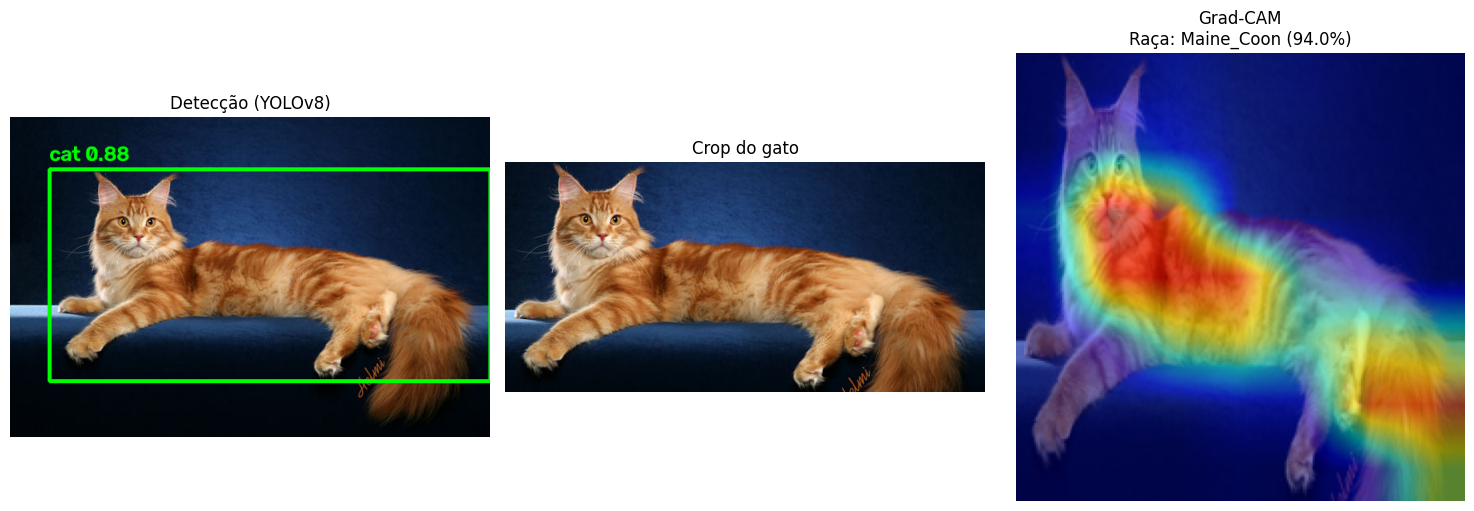

{'bbox': (49, 66, 600, 330), 'detection_conf': 0.8758085370063782, 'breed': 'Maine_Coon', 'breed_conf': 0.940297544002533}


In [ ]:
# Teste rápido com uma imagem do próprio dataset
sample_path = test_df.iloc[200]["filepath"]
result = full_pipeline(sample_path)
print(result)


## 11. Teste em fotos reais (fora do dataset)

Faça upload de fotos próprias (do seu gato, de amigos, da internet com
uso permitido) para testar a generalização do modelo em condições reais:
ângulos diferentes, iluminação ruim, fundo bagunçado, gatos SRD, etc.


In [ ]:
from google.colab import files

uploaded = files.upload()  # selecione uma ou mais imagens do seu computador

real_photos_dir = "/content/real_photos"
os.makedirs(real_photos_dir, exist_ok=True)

real_photo_paths = []
for filename in uploaded.keys():
    dest = os.path.join(real_photos_dir, filename)
    shutil.move(filename, dest)
    real_photo_paths.append(dest)

print("Fotos carregadas:", real_photo_paths)


In [ ]:
results_real = []
for path in real_photo_paths:
    print(f"\n--- {os.path.basename(path)} ---")
    res = full_pipeline(path)
    res["filename"] = os.path.basename(path)
    results_real.append(res)

results_real_df = pd.DataFrame(results_real)
results_real_df


### Anotando os resultados manualmente

Para calcular a "acurácia no mundo real", preencha a coluna `raca_real`
com a raça verdadeira de cada foto (o que você sabe sobre o gato) e
compare com a coluna `breed` (predição do modelo). Gatos SRD/vira-lata
podem ser marcados como `"SRD"` — nesse caso, não há "acerto" possível,
mas é interessante ver qual raça o modelo acha mais parecida.


In [ ]:
# Preencha manualmente a raça verdadeira de cada foto, na mesma ordem de results_real_df
# Exemplo:
# raca_real = ["Siamese", "SRD", "Persian"]

raca_real = [None] * len(results_real_df)  # <-- edite aqui

results_real_df["raca_real"] = raca_real
results_real_df["acertou"] = results_real_df["breed"] == results_real_df["raca_real"]
results_real_df


In [ ]:
avaliados = results_real_df.dropna(subset=["raca_real"])
avaliados = avaliados[avaliados["raca_real"] != "SRD"]

if len(avaliados) > 0:
    acc_real = avaliados["acertou"].mean()
    print(f"Acurácia em fotos reais (excluindo SRD): {acc_real:.1%}  ({len(avaliados)} fotos avaliadas)")
else:
    print("Preencha a coluna 'raca_real' na célula anterior para calcular a acurácia real.")


## 12. Comparação final: dataset de teste vs. fotos reais

Resuma os dois cenários para deixar clara a diferença entre desempenho
"de laboratório" e desempenho no mundo real (domain shift).


In [ ]:
print("=" * 50)
print("RESUMO DOS RESULTADOS")
print("=" * 50)
print(f"Acurácia no dataset de teste (Oxford-IIIT): {acc:.1%}")
print(f"F1-score (macro) no dataset de teste:       {f1:.1%}")
if len(avaliados) > 0:
    print(f"Acurácia em fotos reais (fora do dataset):   {acc_real:.1%}")
print("=" * 50)
print()
print("Análise sugerida:")
print("- Liste aqui os casos de erro em fotos reais e, usando o Grad-CAM,")
print("  identifique se o modelo focou em regiões erradas (fundo, objetos,")
print("  outra parte do corpo) em vez do rosto/pelagem do gato.")


---

## Próximos passos possíveis
- Treinar/fine-tunar o próprio YOLOv8 no dataset de gatos para detecção mais precisa
- Testar outras arquiteturas de classificação (EfficientNet, ConvNeXt)
- Criar uma interface simples com **Gradio** ou **Streamlit** para upload e visualização interativa
- Ampliar o dataset de fotos reais para uma avaliação estatisticamente mais robusta
